# **Experiment #1 Baseline implementation | Results**


Note: _the predictions get retourned as BPR loss. As consequence, the predictions are not in the range of 0 to 1. To interpret them further, we need to convert them to the range of 0 to 1. Use sigmoid function._

## Setup

Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import networkx as nx
import itertools
from collections import defaultdict

import sys
sys.path.append("../..")

from models.KGIL.utils.metrics import (
    gini_coefficient
)
from utils.data_processing import Visualize_KG, KG_Filter, Process_KG

Parameters

In [2]:
MODEL_TECHNIQUES = ["collaborative_filtering", "baseline_flat", "gemma3"]
DATASETS = ["Books", "amazon-All_Beauty", "amazon-Video_Games","Last-FM"]
DATASET = DATASETS[2]
EXPERIMENT_BASELINES = "#1 Baseline Implementation"


current_dir = os.getcwd()
project_root = os.path.dirname(os.path.dirname(os.path.dirname(current_dir)))
PATH_BASELINES = os.path.join(project_root,"data", 'experiments',EXPERIMENT_BASELINES,DATASET)


## Quantitive Performance
### Prediction ranking metrics

In [3]:

current_dir = os.getcwd()
project_root = os.path.dirname(os.path.dirname(os.path.dirname(current_dir)))

REDUNDANCY_STRATEGIES = ["gemma3", "baseline_flat", "collaborative_filtering"]
N_HOPS = ["3","6","9","11"]

relevant_metrics = ["NDCG@20","Recall@20"]
relevant_metrics_df = pd.DataFrame()

metrics_df = pd.DataFrame()
for REDUNDANCY_STRATEGY in REDUNDANCY_STRATEGIES:

    METRICS_PATH = os.path.join(PATH_BASELINES,REDUNDANCY_STRATEGY)
    for N_HOP in N_HOPS:
        n_hops_metrics_df = pd.read_csv(f"{METRICS_PATH}/{N_HOP}-hops_acc_df.csv")
        n_hops_metrics_df["redundancy_strategy"] = REDUNDANCY_STRATEGY
        n_hops_metrics_df["n_hops"] = N_HOP
        metrics_df = pd.concat([metrics_df, n_hops_metrics_df], ignore_index=True)

        for METRIC in relevant_metrics: 
            temp_df = metrics_df[metrics_df["Metric"] == METRIC]
            relevant_metrics_df = pd.concat([relevant_metrics_df, temp_df], ignore_index=True)  

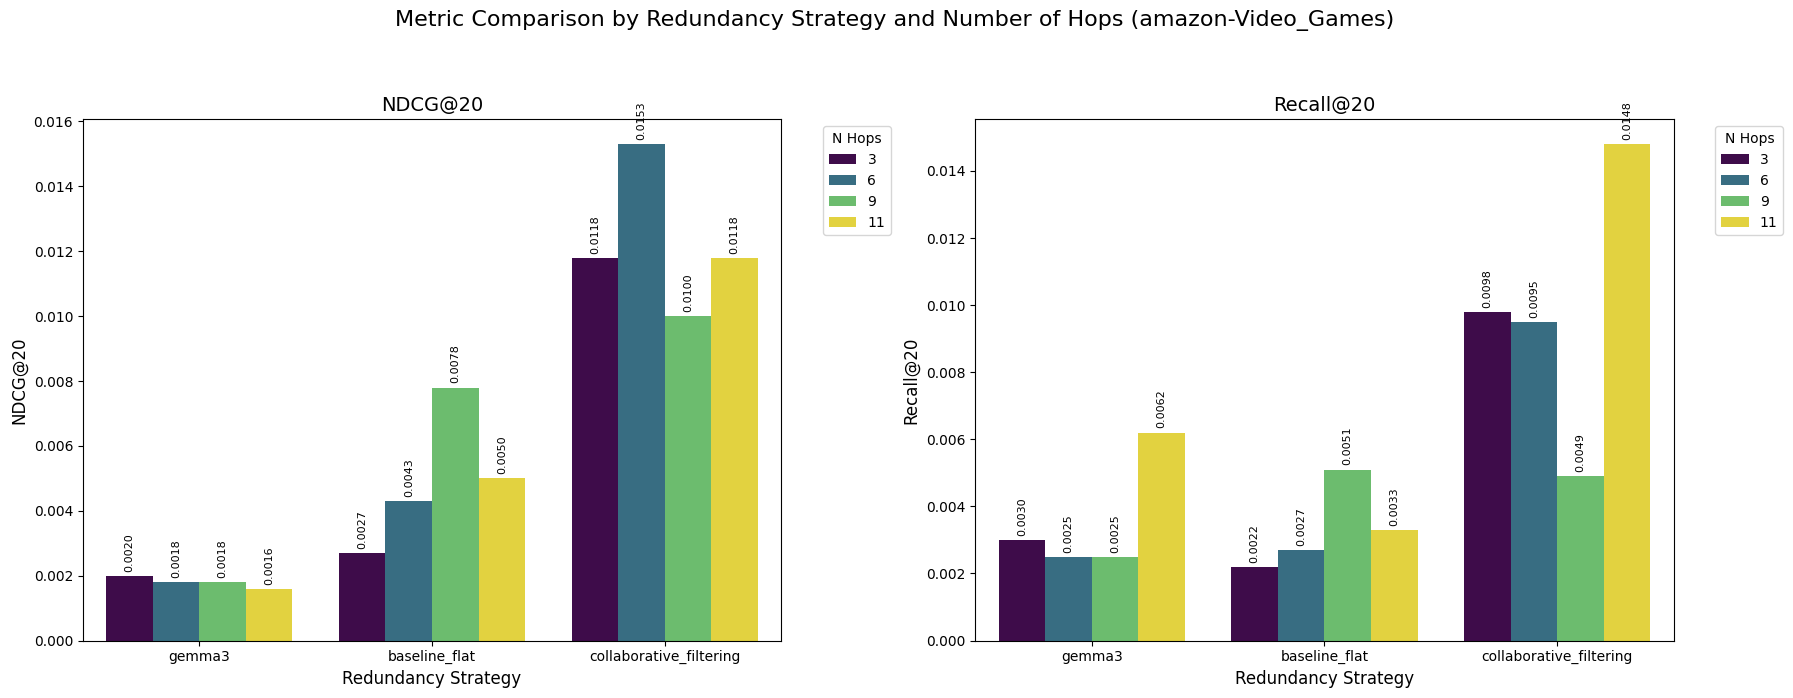

In [95]:
# Ensure n_hops is numeric for sorting and plotting
relevant_metrics_df['n_hops'] = pd.to_numeric(relevant_metrics_df['n_hops'])

# Get unique redundancy strategies and sorted n_hops
strategies = relevant_metrics_df['redundancy_strategy'].unique()
n_hops_order = sorted(relevant_metrics_df['n_hops'].unique())

# Create subplots: one row, two columns (Hit Ratio, Precision)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 7)) # Adjusted figsize for better group display

fig.suptitle(f'Metric Comparison by Redundancy Strategy and Number of Hops ({DATASET})', fontsize=16, y=1.02) # Adjust y for suptitle

# --- Subplot 1: Hit Ratio @ 20 ---
ax1 = axes[0]
# Filter for the specific metric
hr_df = relevant_metrics_df[relevant_metrics_df['Metric'] == 'NDCG@20']
# Plot grouped barplot: x=strategy, hue=n_hops
sns.barplot(data=hr_df, x='redundancy_strategy', y='Value', hue='n_hops', ax=ax1, palette='viridis', hue_order=n_hops_order)
ax1.set_xlabel('Redundancy Strategy', fontsize=12)
ax1.set_ylabel('NDCG@20', fontsize=12)
ax1.set_title('NDCG@20', fontsize=14)
ax1.tick_params(axis='x', rotation=0, labelsize=10)
ax1.tick_params(axis='y', labelsize=10)
ax1.legend(title='N Hops', bbox_to_anchor=(1.05, 1), loc='upper left') # Adjust legend position

# Add value labels on top of bars
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.4f', fontsize=8, padding=3, rotation=90) # Rotate labels if needed

# --- Subplot 2: Precision @ 20 ---
ax2 = axes[1]
# Filter for the specific metric
pr_df = relevant_metrics_df[relevant_metrics_df['Metric'] == 'Recall@20']
# Plot grouped barplot: x=strategy, hue=n_hops
sns.barplot(data=pr_df, x='redundancy_strategy', y='Value', hue='n_hops', ax=ax2, palette='viridis', hue_order=n_hops_order)
ax2.set_xlabel('Redundancy Strategy', fontsize=12)
ax2.set_ylabel('Recall@20', fontsize=12)
ax2.set_title('Recall@20', fontsize=14)
ax2.tick_params(axis='x', rotation=0, labelsize=10)
ax2.tick_params(axis='y', labelsize=10)
ax2.legend(title='N Hops', bbox_to_anchor=(1.05, 1), loc='upper left') # Adjust legend position

# Add value labels on top of bars
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.4f', fontsize=8, padding=3, rotation=90) # Rotate labels if needed

# Adjust layout to prevent titles/labels overlapping
fig.tight_layout(rect=[0, 0.03, 1, 0.97]) # Adjust rect to make space for suptitle

plt.show()

# Resetting figure size here affects subsequent plots, not the one just shown.
# Consider setting rcParams before creating the plot if a default size is desired for this specific plot.
plt.rcParams['figure.figsize'] = [18, 10] # Example: Set default for future plots


Interpretation of Performance Metrics vs. Hops (Video Games Dataset)
 
 The plots above visualize two common recommendation system evaluation metrics, NDCG@20 and Recall@20, across different knowledge graph construction methods and varying numbers of hops (graph traversal depth) used during recommendation generation.
 
Metric Definitions:
 
 *   **NDCG@20 (NDCG@20):** measures the normalized discounted cumulative gain of the top 20 recommended items. It is a measure of the quality of the recommendation list, taking into account the relevance of the items and their position in the list. A higher NDCG@20 indicates that the model is better at recommending relevant items at the top of the list.
 *   **Recall@20 (R@20):** measures the proportion of relevant items in the top 20 recommendations. It is a measure of the model's ability to retrieve relevant items. A higher R@20 indicates that the model is better at recommending relevant items.
 
 Performance Analysis:
 
 1.  **Overall Performance:**
+ The `LLM-Col-Hierarchy-Tax` baseline implementation achieves the lowest performance scores compared to both `baseline_flat` and `collaborative filtering` approaches. 
+ Specifically, the collaborative filtering baseline achieves NDCG@20 (0.0118) and Recall@20 (0.0098) without using any additional information. 
+ The hierarchical taxonomy approach without post-processing may have introduced unnecessary complexity and noise in the recommendation process, which could confuse the GNN model rather than enhancing its performance.

 
 2.  **Impact of Number of Hops:**
+   A key observation from both plots for the Video Games dataset is that the **number of hops (ranging from 3 to 13)  be dependen on technique appears to have an impact on the performance**.
+   The performance metrics show that NDCG@20 performs best at 6 hops while Recall@20 performs best at 11 hops, with relatively small differences between these hop counts. 
+ Because of the dependcy towards technique we cant formulize a general trend. Looking at the Metrics LLM-COL-Hierarchy-Tax we observe for the NDCG@20 that more hops continiously worsen the metric. The same trend we observe for the Recall@20 with the exception that at 11 hops the approach metric jumps all of the sudden. 
  
    
 Conclusion:
From now we have a baseline for the `LLM-Col-Hierarchy-Tax` method. We can now start to look how to improve their performance by enhancing the technique. Interestingly, increasing the graph traversal depth trend wasnt uniform. Further expeirments might help identify sweet spots. 

### Confusion Matrix

In [5]:
MODEL_TECHNIQUE = "gemma3"
MODEL_TECHNIQUE_NAME = MODEL_TECHNIQUE.replace("/", "_")
TAXONOMY_PATH = os.path.join(project_root,"data","taxonomy",DATASET)
METADATA_PATH = os.path.join(project_root,"data","preprocessed",DATASET)
EXPERIMENT_DATA_PATH = os.path.join(project_root,"data","experiments","#1 Baseline Implementation",DATASET,MODEL_TECHNIQUE)

N_HOPS = 3

df_metadata = pd.read_csv(f"{METADATA_PATH}/metadata_filtered_df.csv") # contains the metadata for items
df_test = pd.read_csv(f"{METADATA_PATH}/test_df.csv") # contains the test set
df_train = pd.read_csv(f"{METADATA_PATH}/train_df.csv") # contains the train set

error_df = pd.read_csv(f"{EXPERIMENT_DATA_PATH}/{N_HOPS}-Hops_predictions.csv") # contains the predictions
gemma_mapping = pd.read_csv(f"{EXPERIMENT_DATA_PATH}/entity_map.csv") # to convert ids to entity names
gemma_relation = pd.read_csv(f"{TAXONOMY_PATH}/{MODEL_TECHNIQUE_NAME}_taxonomy-triples-full1.csv") # contains the relations between items and hierarhcy
metrics_df = pd.read_csv(f"{EXPERIMENT_DATA_PATH}/{N_HOPS}-hops_acc_df.csv")
error_df["user_id"] = error_df["user_id"].map(gemma_mapping.set_index("id")["entity"])
error_df["item_id"] = error_df["item_id"].map(gemma_mapping.set_index("id")["entity"])


In [6]:
process_kg = Process_KG()
error_df = process_kg.process_prediction(error_df)


In [ ]:
import numpy as np
import heapq


import pandas as pd
import numpy as np
import heapq
from models.KGIL.utils.metrics import recall_at_k, ndcg_at_k # CRITICAL: Ensure these are your project's functions

K=20


def evaluate_random_baseline(predictions_df: pd.DataFrame, k_value: int = 20) -> dict:
    """
    Evaluates a random baseline based on coin toss predictions, calculating
    Recall@K and NDCG@K.

    Args:
        predictions_df (pd.DataFrame): DataFrame with columns
                                       ['user_id', 'item_id', 'actual', 'random_value'].
                                       'actual' is 1 if true interaction, 0 otherwise.
                                       'random_value' is 0 or 1 from coin_toss, used for ranking.
        k_value (int): The K for top-K metrics (default is 20).

    Returns:
        dict: A dictionary containing aggregated metrics:
              {'recall@K': float, 'ndcg@K': float}
    """
    
    required_columns = ['user_id', 'item_id', 'actual', 'random_value']
    if not all(col in predictions_df.columns for col in required_columns):
        raise ValueError(f"Input DataFrame must contain columns: {required_columns}")

    aggregated_metrics = {
        f'recall@{k_value}': 0.0,
        f'ndcg@{k_value}': 0.0,
    }

    test_users = predictions_df['user_id'].unique()
    n_test_users = len(test_users)

    if n_test_users == 0:
        print("No test users found in the predictions DataFrame.")
        return {key: 0.0 for key in aggregated_metrics}

    processed_users = 0
    for user_id in test_users:
        user_data = predictions_df[predictions_df['user_id'] == user_id].copy()
        
        # Actual positive items for the user (this is a set of item IDs)
        user_pos_test_items = set(user_data[user_data['actual'] == 1]['item_id'])
        # Count of actual positive items for the user (this is an int)
        num_user_pos_test_items = len(user_pos_test_items)
        
        # Create item_score dictionary: item_id -> random_value + tiny random for tie-breaking
        user_data['tie_breaker_score'] = user_data['random_value'] + np.random.uniform(0, 0.00001, size=len(user_data))
        item_scores = pd.Series(user_data['tie_breaker_score'].values, index=user_data['item_id']).to_dict()

        if not item_scores:
            continue

        num_items_to_rank = min(k_value, len(item_scores))
        ranked_item_ids = heapq.nlargest(num_items_to_rank,
                                         item_scores, 
                                         key=item_scores.get)
        
        r_list_for_metrics = []
        for item_id_in_ranking in ranked_item_ids:
            if item_id_in_ranking in user_pos_test_items:
                r_list_for_metrics.append(1)
            else:
                r_list_for_metrics.append(0)
        
        while len(r_list_for_metrics) < k_value:
            r_list_for_metrics.append(0)
            
        if num_user_pos_test_items > 0:
            # recall_at_k expects the count of positive items
            aggregated_metrics[f'recall@{k_value}'] += recall_at_k(r_list_for_metrics, k_value, num_user_pos_test_items)
            # ndcg_at_k expects the set of ground truth positive items
            aggregated_metrics[f'ndcg@{k_value}'] += ndcg_at_k(r_list_for_metrics, k_value, user_pos_test_items) 
        else:
            aggregated_metrics[f'recall@{k_value}'] += 0.0
            aggregated_metrics[f'ndcg@{k_value}'] += 0.0
        
    if n_test_users > 0:
        for key in aggregated_metrics:
            aggregated_metrics[key] /= n_test_users
    
    return aggregated_metrics


def coin_toss(df: pd.DataFrame, seed: int = None) -> pd.DataFrame:
    if seed is not None:
        np.random.seed(seed)
    pred = np.random.choice([0,1], size=len(df))
    df["random_value"] = pred
    return df

error_df_random = error_df.filter(items=["user_id", "item_id", "actual", "random_value"])

N_RUNS = 20

# Store metrics for each run
all_recall = []
all_ndcg = []

for i in range(N_RUNS):
    random_seed = np.random.randint(0, 1000000)
    error_df_with_random = coin_toss(error_df.copy(), random_seed) 
    run_metrics = evaluate_random_baseline(error_df_with_random, k_value=20)
    all_recall.append(run_metrics['recall@20'])
    all_ndcg.append(run_metrics['ndcg@20'])

# Calculate mean metrics
mean_recall = np.mean(all_recall)
mean_ndcg = np.mean(all_ndcg)

print(f"\nRandom Baseline Metrics @20 (mean across {N_RUNS} runs):")
print(f"recall@20: {mean_recall:.4f}")
print(f"ndcg@20: {mean_ndcg:.4f}")



Random Baseline Metrics @20 (mean across 20 runs):
recall@20: 0.0017
ndcg@20: 0.0007



Delta between 6-hop and Random Baseline Metrics @20:
delta_ndcg: 0.0013
delta_recall: 0.0013


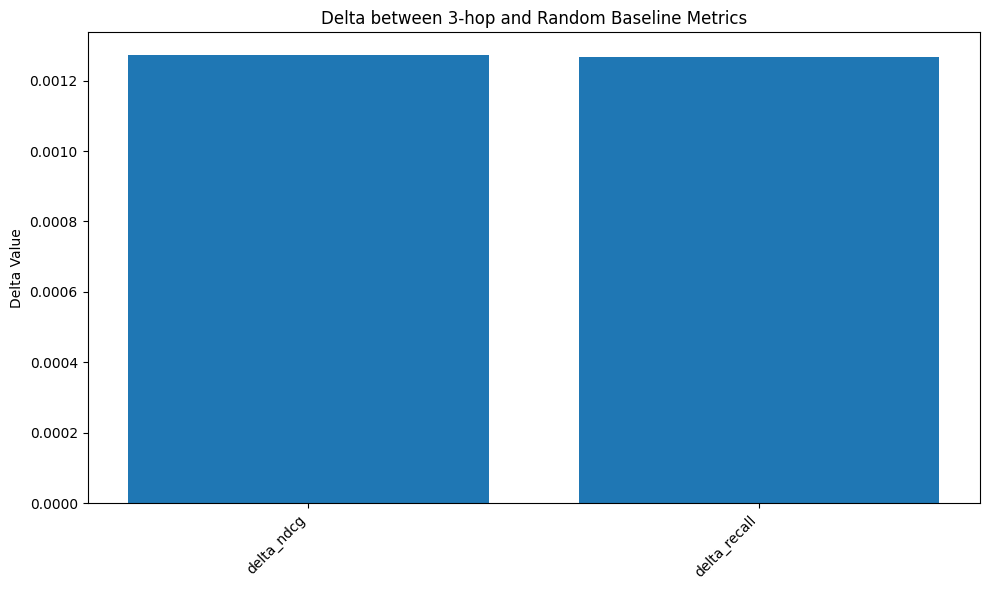

In [ ]:
# Calculate delta between 6-hop metrics and baseline metrics

# Extract metrics from six_hops DataFrame

six_hops_ndcg_20 = metrics_df[metrics_df["Metric"] == "NDCG@20"]["Value"].values[0]
six_hops_recall_20 = metrics_df[metrics_df["Metric"] == "Recall@20"]["Value"].values[0]

# Create dictionary to store deltas
delta_metrics = {}

# Calculate deltas for each metric

delta_ndcg = six_hops_ndcg_20 - mean_ndcg
delta_recall = six_hops_recall_20 - mean_recall

delta_metrics[f'delta_ndcg'] = delta_ndcg
delta_metrics[f'delta_recall'] = delta_recall

print("\nDelta between 6-hop and Random Baseline Metrics @20:")
for metric, value in delta_metrics.items():
    print(f"{metric}: {value:.4f}")

# Create a bar plot to visualize the deltas
plt.figure(figsize=(10, 6))
metrics = list(delta_metrics.keys())
values = list(delta_metrics.values())

plt.bar(metrics, values)
plt.xticks(rotation=45, ha='right')
plt.title('Delta between 3-hop and Random Baseline Metrics')
plt.ylabel('Delta Value')
plt.tight_layout()
plt.show()


In [91]:
# Calculate percentage deltas
delta_metrics_percent = {}

delta_ndcg_percent = (delta_ndcg / mean_ndcg) * 100
delta_recall_percent = (delta_recall / mean_recall) * 100

delta_metrics_percent['delta_ndcg_percent'] = delta_ndcg_percent
delta_metrics_percent['delta_recall_percent'] = delta_recall_percent

print("\nDelta between 3-hop and Random Baseline Metrics @20 (in percentages):")
for metric, value in delta_metrics_percent.items():
    print(f"{metric}: {value:.2f}%")



Delta between 3-hop and Random Baseline Metrics @20 (in percentages):
delta_ndcg_percent: 175.13%
delta_recall_percent: 73.18%


**Model Performance Analysis: Learning Signal Detection**

The GNN-KG model shows releatively low performances on the ranking metrics for all hop configurations. To validate that the model learned patterns instead of just guessing we compare for the 6 hops configuration the Recall@20 and NDCG@20 with a coin flip. 

The comparisom provides a minimun sanity check. In the scenario the model predicts with even probabilty for all user item tuples in the evaluation phase if the item is relevant (1) or not (0). We run this experiment 20 times to make sure the results become more random seed independent. 

Looking at the chart above we see that after 20 runs.
The GNN KG using the LLM-COL-Hierarchy-Tay model has superiour performance to the random guessing baseline for ranking metrics. Hencing the model is able to learn a signal.

In [ ]:
error_df = process_kg.count_hits(error_df)
error_df = process_kg.connect_parents(error_df, gemma_relation)

Accuracy in test set: 0.5652882461730762


Entity counts and density:
                   tail  count  density
             Xbox Games   1869 0.077542
      PlayStation Games   1782 0.073933
                  Games   1758 0.072937
               PC Games   1728 0.071692
         Nintendo Games   1693 0.070240
               Nintendo   1386 0.057503
          PlayStation 4   1276 0.052939
          PlayStation 5   1253 0.051985
            PlayStation   1227 0.050907
     Gaming Accessories    943 0.039124
                   Xbox    925 0.038377
               Xbox One    916 0.038004
   Nintendo Controllers    809 0.033564
PlayStation Controllers    775 0.032154
           Nintendo 3DS    676 0.028046
       PlayStation Vita    674 0.027963
        Nintendo Switch    655 0.027175
     Gaming Peripherals    612 0.025391
          Xbox Series S    595 0.024686
       Xbox Controllers    536 0.022238
          Xbox Series X    429 0.017799
   Nintendo Switch Lite    295 0.012239
            Controllers    288 0.011949
        Gamin

<Axes: xlabel='count', ylabel='Density'>

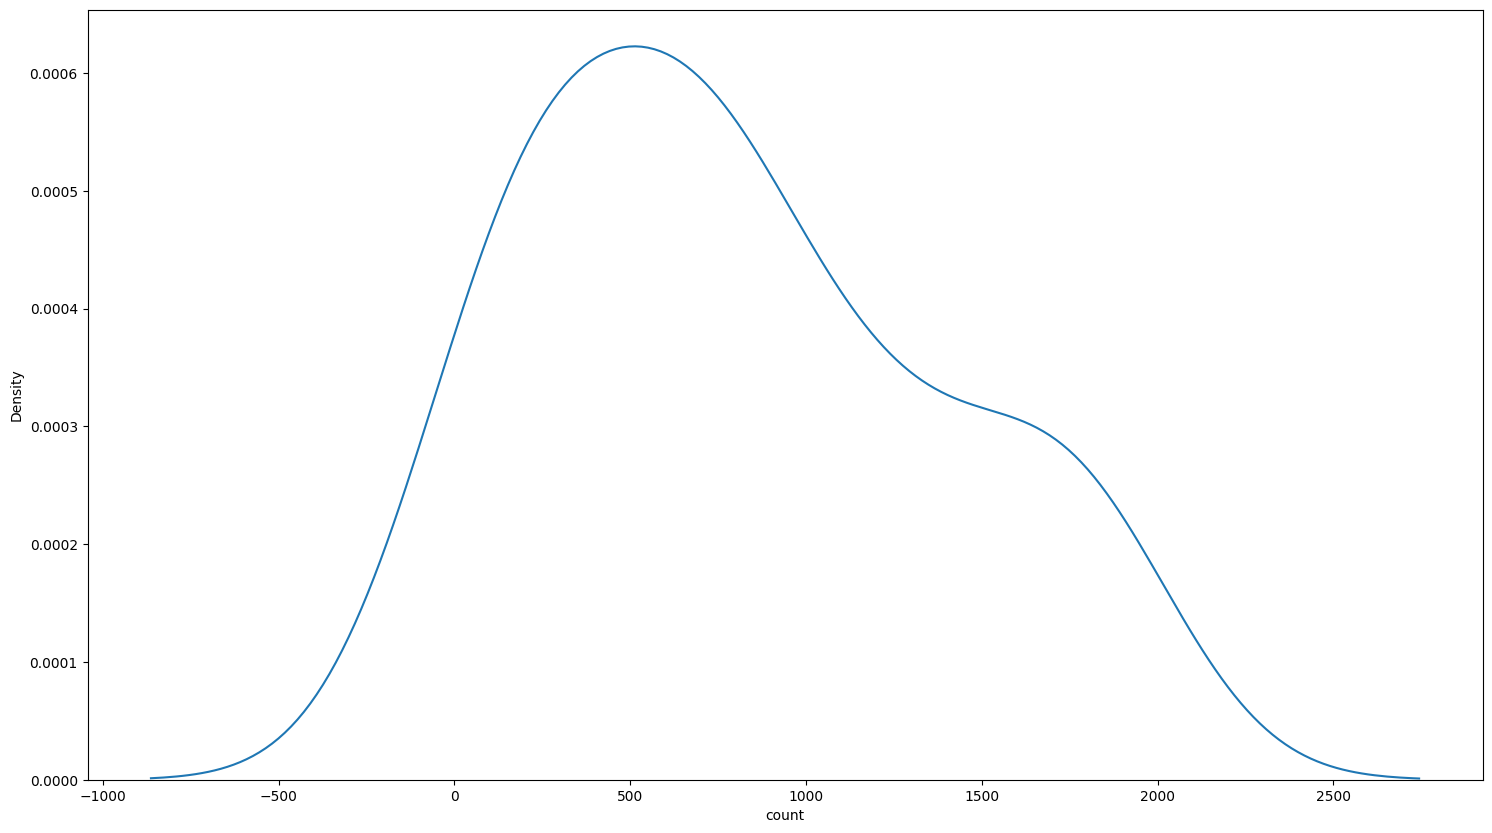

In [9]:
# Group by entity and count entries
entity_counts = gemma_relation.groupby('tail').size().reset_index(name='count')
entity_counts['density'] = entity_counts['count'] / len(gemma_relation)

# Sort by count in descending order and display
entity_counts = entity_counts.sort_values('count', ascending=False)
print("Entity counts and density:")
print(entity_counts.to_string(index=False))

sns.kdeplot(entity_counts["count"])

In [10]:
error_df = error_df.drop_duplicates(subset=["user_id", "item_id"], keep="first")

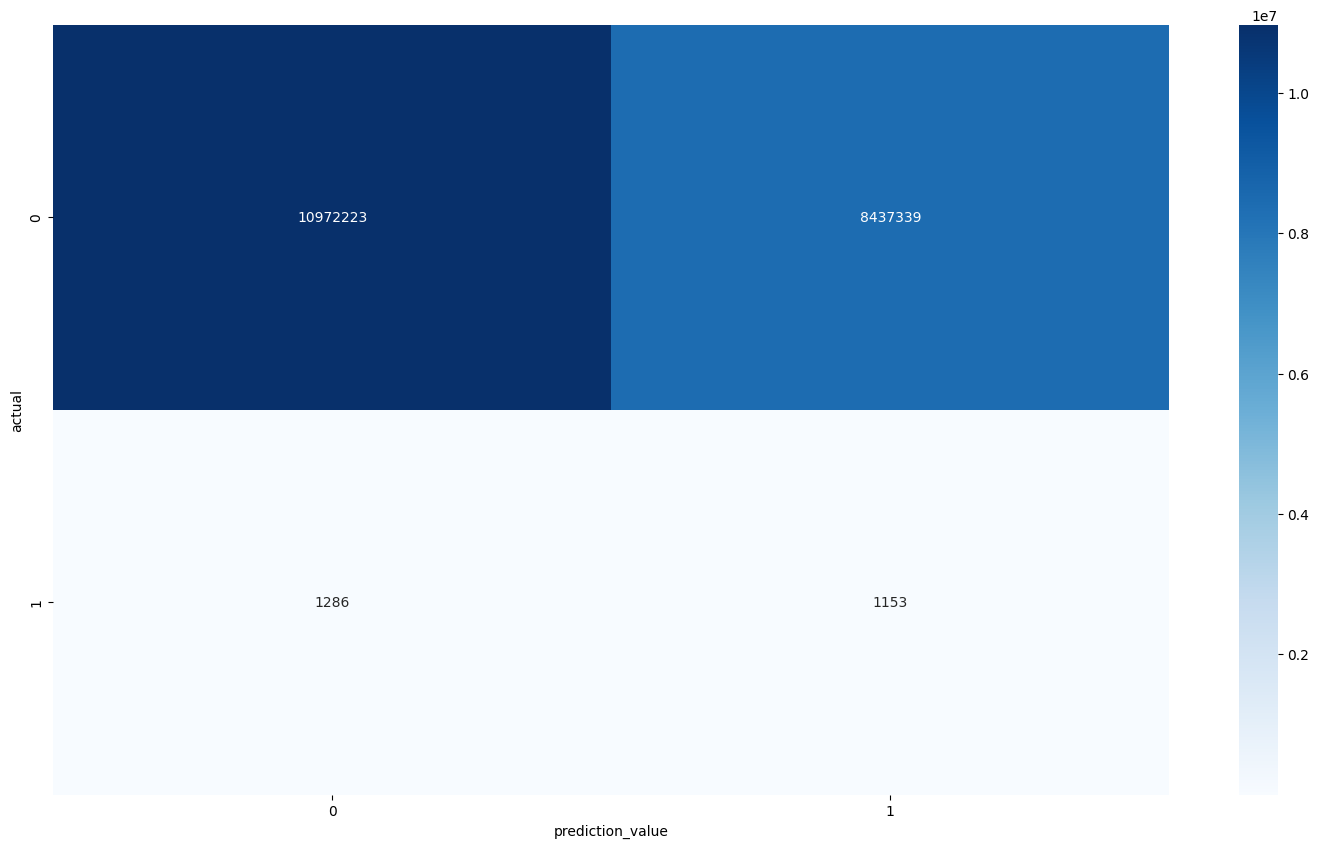

In [16]:
# confusion matrix
confusion_matrix = pd.crosstab(error_df["actual"], error_df["prediction_value"])

# draw confusion matrix
sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues")
plt.show()


 The confusion matrix analysis reveals a classification accuracy of approximately 57% on the negative sampling dataset, indicating suboptimal discriminative performance of the LLM-COL-HIERARCHY-TAX model in distinguishing between positive and negative item interactions. The confusion matrix exhibits nearly balanced distributions between false negatives and true positives, suggesting limited predictive capability. Furthermore, the model demonstrates a substantial false positive rate with approximately 8.5 million misclassified instances, while having similiar amount of true negatives with 10.9 million.. 
 
The overall confusion matrix pattern indicates that the GNN-KG model exhibits partial learning capacity, successfully identifying negative items while maintaining a high false positive prediction rate. This observation suggests that while the model has acquired some discriminative patterns, it requires further optimization to improve its classification performance.

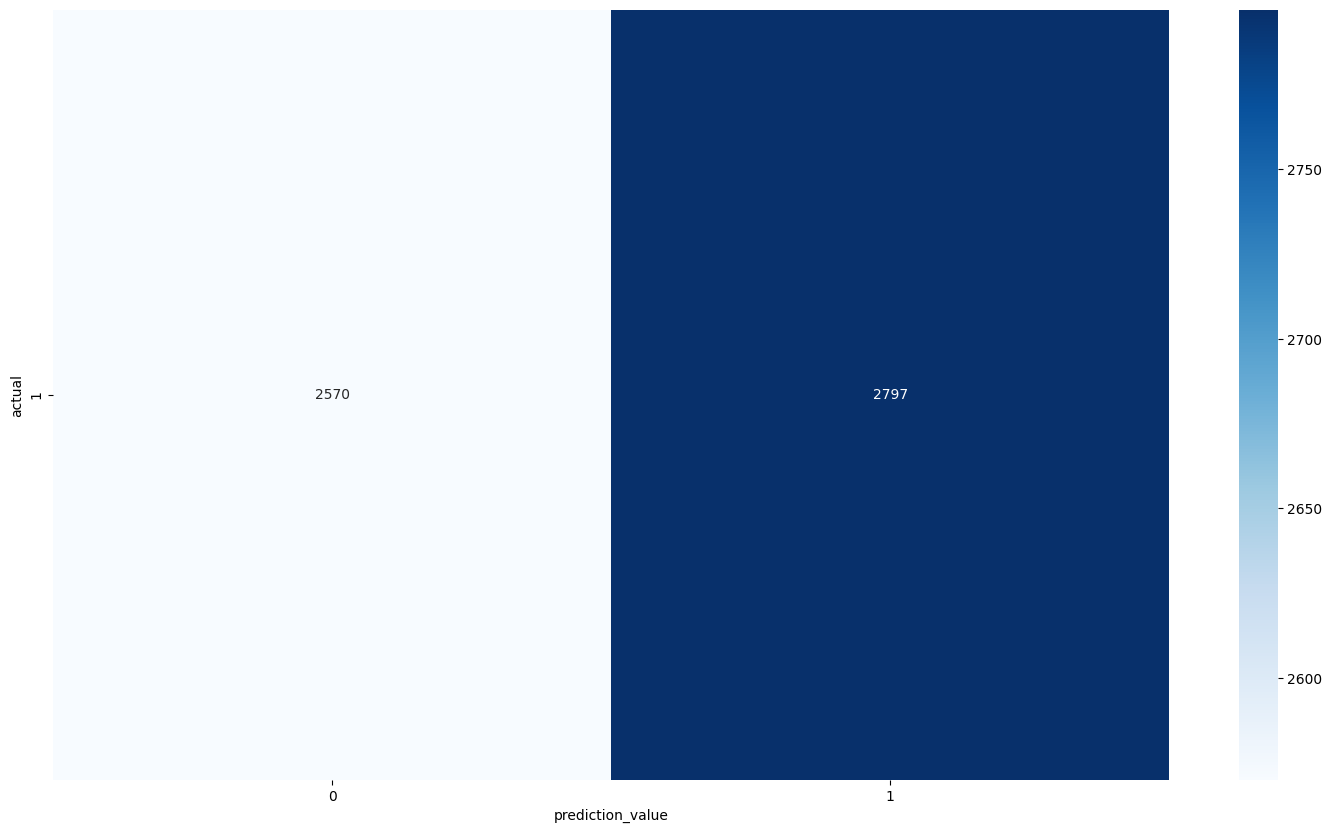

In [17]:
error_df_test = pd.merge(error_df, df_test, left_on=["user_id", "item_id"], right_on=["user_id", "parent_asin"], how="inner")
error_df_test['__temp_is_rating_nan__'] = error_df_test['rating'].isna()

error_df_test = error_df_test.sort_values(
    by=['user_id', 'item_id', '__temp_is_rating_nan__'],
    ascending=[True, True, False] 
)

error_df_test = error_df_test.drop_duplicates(subset=['user_id', 'item_id'], keep='first')
error_df_test["actual"] = 1
# Remove the temporary column.
error_df_test = error_df_test.drop(columns=['__temp_is_rating_nan__'])
confusion_matrix_test = pd.crosstab(error_df_test["actual"], error_df_test["prediction_value"])

sns.heatmap(confusion_matrix_test, annot=True, fmt="d", cmap="Blues")
plt.show()


The knowledge graph GNN model demonstrates balanced prediction behavior on the test set, with ratio 1:1.08 of true positives to false positives. This indicates the model only partially identifies relevant items while maintaining a reasonable rate of misclassifying relevant items as irrelevant. To further validate this balanced performance, we examine the top-20 recommendations per user.

Actual values in top K predictions:  actual
0    16250
1       10
Name: count, dtype: int64
Accuracy in test set: 0.0006150061500615006


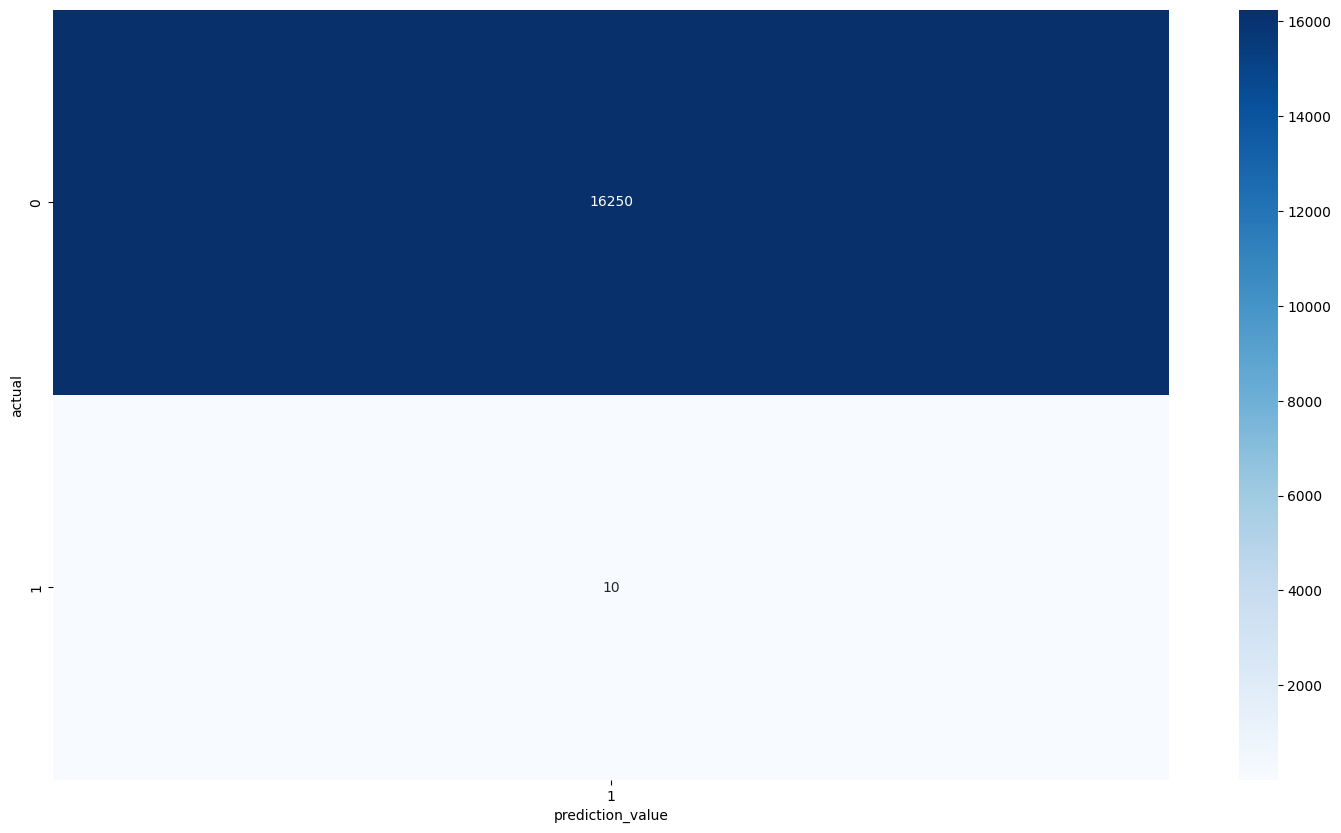

In [18]:
error_df_at_k = error_df.sort_values(by=["user_id","prediction"], ascending=True)
error_df_at_k = error_df_at_k.groupby("user_id").tail(20)
print("Actual values in top K predictions: ",error_df_at_k["actual"].value_counts())
error_df_at_k = process_kg.process_prediction(error_df_at_k)
error_df_at_k = process_kg.count_hits(error_df_at_k)
# confusion matrix
confusion_matrix = pd.crosstab(error_df_at_k["actual"], error_df_at_k["prediction_value"])

# draw confusion matrix
sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues")
plt.show()


In the top 20 recommendations for each user the model majorly predicts false posotives (16.250) and is only able to hit 10 user-item interactions. Means the model is not able to rank relevant items higher than irrelevant items.

This trend might be due to the fact that the model is biased towards predicting items that are associated to the most popular parent entities. To observe this bias we want to look at the first, second and third level parents of the items.

In [19]:
error_df["fourth_level_parent"].value_counts()


fourth_level_parent
Nintendo Switch    452028
VR Headsets          8943
Xbox Series X        2439
Name: count, dtype: int64

In [76]:
collab_map = pd.read_csv("/Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1 Baseline Implementation/amazon-Video_Games/collaborative_filtering/entity_map.csv")
collab_error = pd.read_csv("/Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#1 Baseline Implementation/amazon-Video_Games/collaborative_filtering/6-Hops_predictions.csv")
collab_error = process_kg.process_prediction(collab_error)
collab_error = collab_error[collab_error["prediction_sigmoid"] > 0.5]

collab_item_count = collab_error.groupby("item_id").count()
gini_coefficient(collab_item_count["prediction_value"], "gini index for collaborative filtering for items")

Gini score gini index for collaborative filtering for items: 0.27


0.2739867656348856

In [72]:
error_df = error_df[error_df["prediction_sigmoid"] > 0.5]
#error_df_first_level = error_df.groupby("first_level_parent").count()
error_df_item_count = error_df.groupby("item_id").count()
#gini_coefficient(error_df_first_level["prediction_value"], "gini index for llm col for first level parents")
gini_coefficient(error_df_item_count["prediction_value"], "gini index for llm col for items")


Gini score baseline for items: 0.10


0.10304649717117137

- The Gini index measures inequality in recommendation distributions (0 = perfect equality, 1 = maximum inequality).
 - Collaborative filtering baseline: Gini index = 0.27 → moderate popularity bias; recommendations are concentrated on popular items.
#- LLM col baseline: Gini index = 0.10 → much lower bias; recommendations are more evenly spread, likely due to richer context from the knowledge graph.
#- Lower Gini index in LLM col suggests improved fairness/diversity, but worse accuracy metrics may result from issues in the knowledge graph (e.g., poor structure, redundancies).


In [13]:
error_df.head()
wrong_prediction = pd.DataFrame(error_df[error_df["prediction_correct"] == False])
wrong_prediction 

,user_id,item_id,prediction,actual,prediction_sigmoid,prediction_value,prediction_correct,prediction_positive,prediction_negative,first_level_parent,second_level_parent,third_level_parent,fourth_level_parent
0,AEUAL3EJKUSTNB4YY6STLYGTJALA,AFW2PDT3AMT4X3PYQG7FJZH5FXFA,0.292788,0,0.572679,1,False,True,False,NaN,NaN,NaN,NaN
1,AEUAL3EJKUSTNB4YY6STLYGTJALA,AHV6QCNBJNSGLATP56JAWJ3C4G2A,0.126863,0,0.531673,1,False,True,False,NaN,NaN,NaN,NaN
2,AEUAL3EJKUSTNB4YY6STLYGTJALA,AECGR42H24LUU7DA7HEUMCRLTX7Q,0.146019,0,0.536440,1,False,True,False,NaN,NaN,NaN,NaN
3,AEUAL3EJKUSTNB4YY6STLYGTJALA,AEUAL3EJKUSTNB4YY6STLYGTJALA,0.030001,0,0.507500,1,False,True,False,NaN,NaN,NaN,NaN
5,AEUAL3EJKUSTNB4YY6STLYGTJALA,AHU2GG5RF6YAEWUFNLH3QH5RHDNQ,0.577618,0,0.640519,1,False,True,False,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
59655494,AFYKNU7BHRZDQ67KZDAJFIWKQ24Q,B0BN2CF2P8,0.000141,0,0.500035,1,False,True,False,NaN,NaN,NaN,NaN
59655496,AFYKNU7BHRZDQ67KZDAJFIWKQ24Q,B0948BRTM4,0.002225,0,0.500556,1,False,True,False,NaN,NaN,NaN,NaN
59655497,AFYKNU7BHRZDQ67KZDAJFIWKQ24Q,B0BVTTXYK4,0.000775,0,0.500194,1,False,True,False,NaN,NaN,NaN,NaN
59655499,AFYKNU7BHRZDQ67KZDAJFIWKQ24Q,B09YL9VRVB,0.002787,0,0.500697,1,False,True,False,NaN,NaN,NaN,NaN


To understand the systematic error we want to look at the Subgraph of items that has the highest error margin.

In [14]:
gemma_relation = pd.read_csv("/Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/taxonomy/amazon-Video_Games/gemma3_taxonomy-triples-full1.csv")

In [15]:
wrong_prediction_item = df_metadata[df_metadata["parent_asin"] == wrong_prediction["item_id"].tail(1).iloc[0]]
wrong_prediction_item = wrong_prediction_item["parent_asin"].iloc[0]


Full taxonomy without item bridges


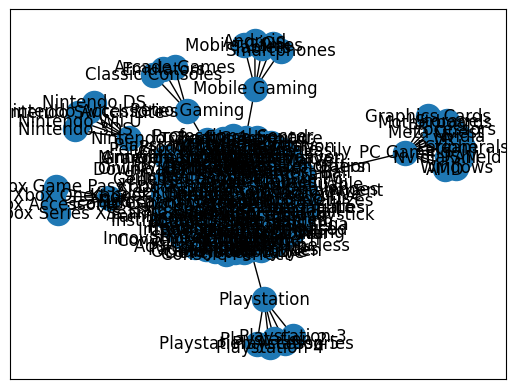

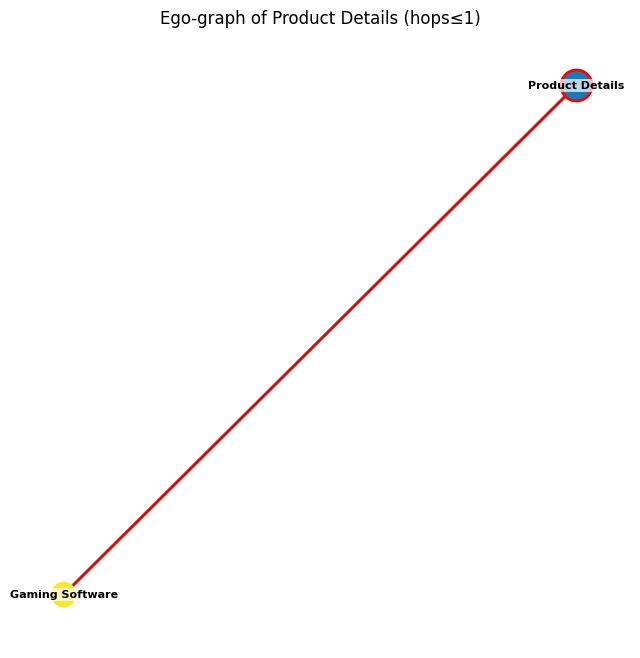

 **Product details** is the center parent node of the taxonomy


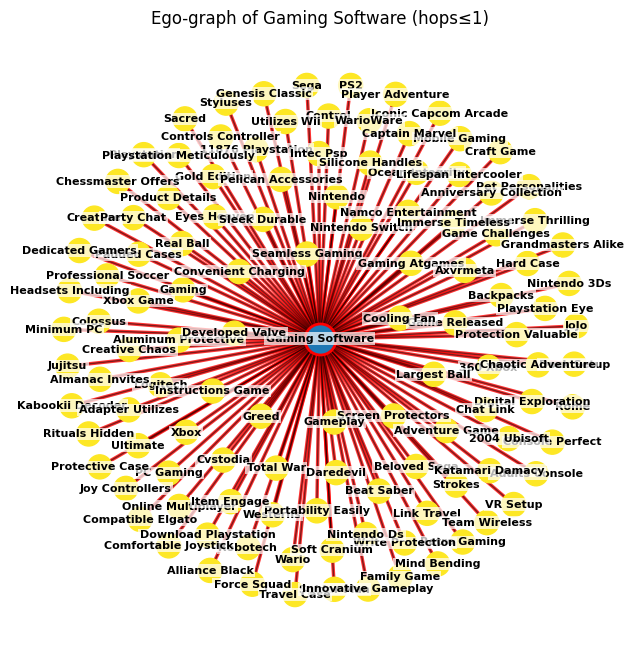

In [7]:
gemma_relation_wo_products = gemma_relation.iloc[:154]

g_taxonomy = nx.from_pandas_edgelist(gemma_relation_wo_products, source='head', target='tail')
nx.draw_networkx(g_taxonomy)

viz = Visualize_KG()
print("Full taxonomy without item bridges")
viz.draw_ego_hops(g_taxonomy, center_node="Product Details", hops=1)
print(" **Product details** is the center parent node of the taxonomy")
viz.draw_ego_hops(g_taxonomy, center_node="Gaming Software", hops=1)

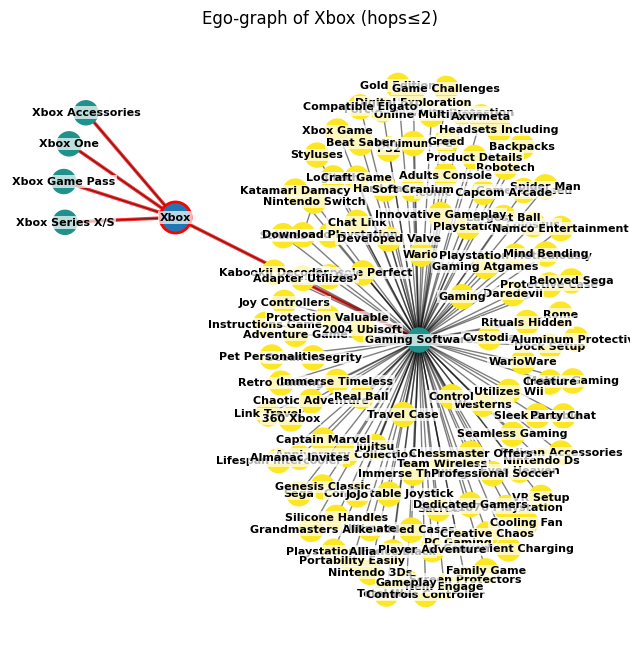

In [30]:
viz.draw_ego_hops(g_taxonomy, center_node="Xbox", hops=2)

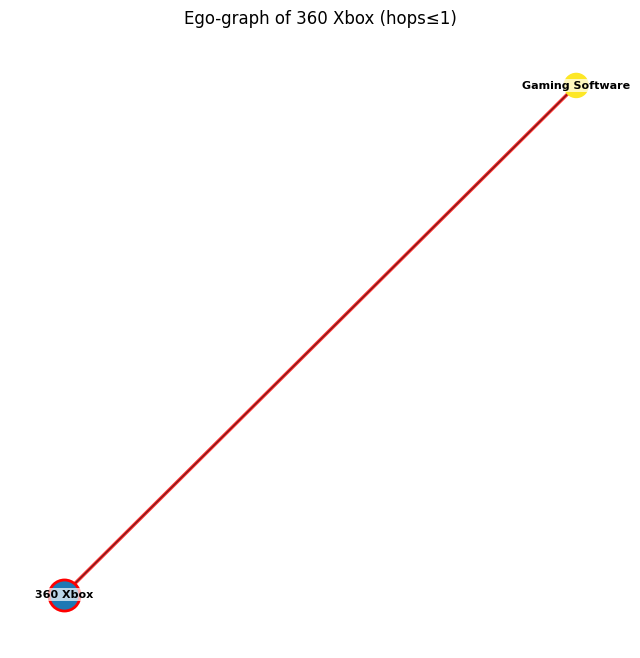

In [37]:
viz.draw_ego_hops(g_taxonomy, center_node="360 Xbox", hops=1)

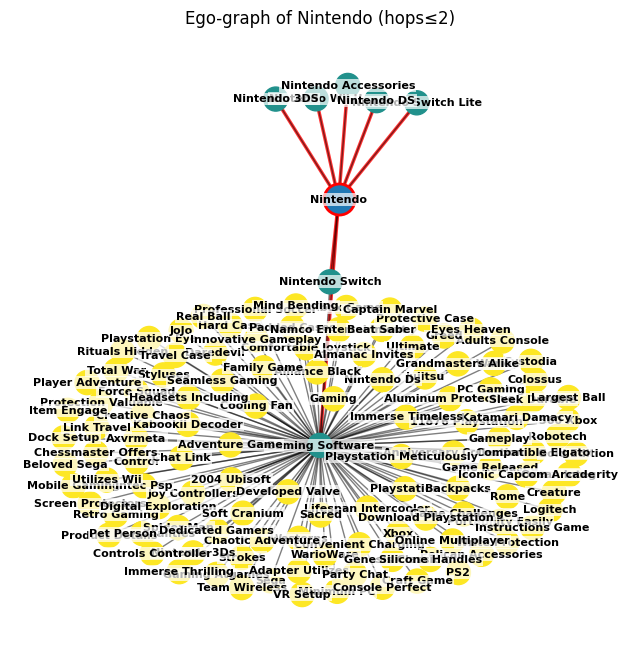

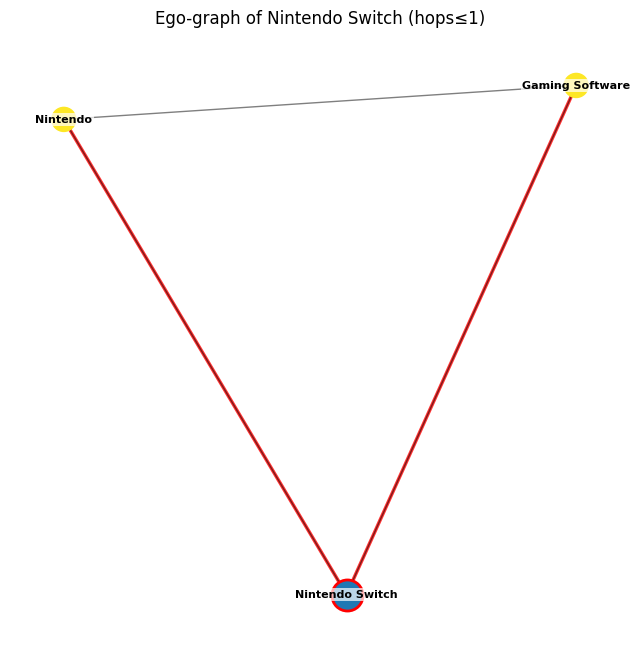

In [42]:
viz.draw_ego_hops(g_taxonomy, center_node="Nintendo", hops=2)
viz.draw_ego_hops(g_taxonomy, center_node="Nintendo Switch", hops=1)

Above we can observe multiple structure patterns of the generated taxonomy 

- The taxonomy is `4 levels deep`
    - E.g. Product details -> Gaming Software -> Xbox -> Xbox One
- The taxonomy `doesnt follow strict tree rules`.
    +  Some Parent Nodes only contain one child node
        + E.g Product details -> Gaming Software
    + Other nodes are redundant cyclic connected
        + E. g. Gaming Software -> Nintendo, Gaming Software -> Nintendo Switch, Nintendo Switch -> Nintendo
- Additionally `some facts` in the taxonomy are `false`, which decrease correctness of taxonomy
    + Nintendo Switch in the taxonomy is illustrated as parent of Nintendo, while in real world the association is the other way around. 
- Taxonomy might lack low affinity of chils to parents
    + We observe a lot of direct bridges of fine granular entities to the second level entity "Gaming Software"
        + E.g. Spider Man has direct link to Gaming Software, while likely a intermediate parent like "Games" or similar might help decrease concentration on the higher level parent


In [8]:
centrality = nx.centrality.degree_centrality(g_taxonomy)
dict(sorted(centrality.items(), key=lambda item: item[1], reverse=True))

{'Gaming Software': 0.7712418300653595,
 'PC Gaming': 0.09150326797385622,
 'Nintendo': 0.04575163398692811,
 'Playstation': 0.0392156862745098,
 'Mobile Gaming': 0.0392156862745098,
 'Xbox': 0.032679738562091505,
 'Retro Gaming': 0.026143790849673203,
 'Nintendo Switch': 0.013071895424836602,
 'Product Details': 0.006535947712418301,
 'Xbox Series X/S': 0.006535947712418301,
 'Xbox One': 0.006535947712418301,
 'Xbox Game Pass': 0.006535947712418301,
 'Xbox Accessories': 0.006535947712418301,
 'Playstation 5': 0.006535947712418301,
 'Playstation 4': 0.006535947712418301,
 'Playstation 3': 0.006535947712418301,
 'Playstation 2': 0.006535947712418301,
 'Playstation Accessories': 0.006535947712418301,
 'Nintendo Wii U': 0.006535947712418301,
 'Nintendo 3DS': 0.006535947712418301,
 'Nintendo Switch Lite': 0.006535947712418301,
 'Nintendo DS': 0.006535947712418301,
 'Nintendo Accessories': 0.006535947712418301,
 'Windows': 0.006535947712418301,
 'Steam': 0.006535947712418301,
 'Nvidia': 0.0

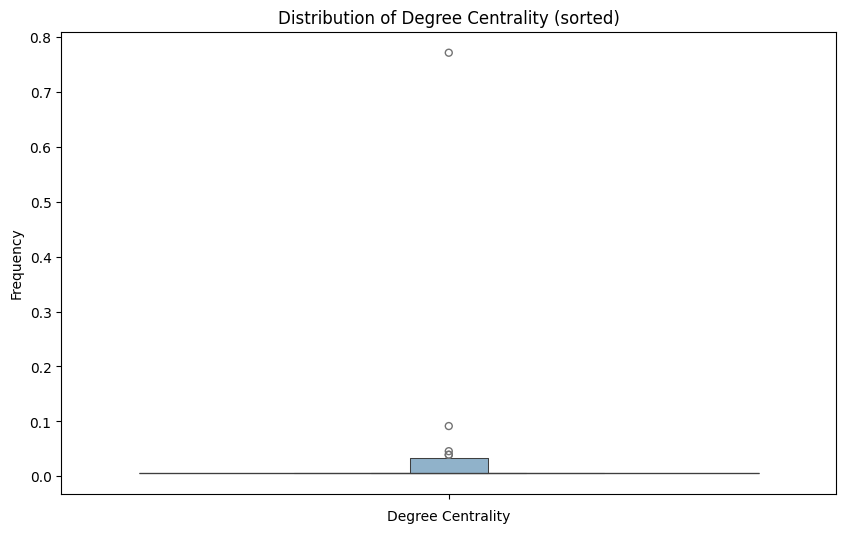

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get sorted degree centrality values
centrality_values = sorted(centrality.values(), reverse=True)

plt.figure(figsize=(10,6))
sns.boxenplot(centrality_values)
plt.title("Distribution of Degree Centrality (sorted)")
plt.xlabel("Degree Centrality")
plt.ylabel("Frequency")
plt.show()


 
+ To systematically analyze the structure of the generated knowledge graph (KG), we examine the degree centrality of its nodes. Degree centrality quantifies the number of direct connections a node has, providing insight into how "central" or "important" a node is within the network based on immediate links.

 + The degree centrality distribution is highly skewed: most nodes have low centrality, but a few high-level entities (e.g., "Gaming Software") act as hubs with exceptionally high centrality, indicating many items link "greedy" directly to these top-level nodes rather than through intermediate categories.


In [55]:
# filter out item 7100027950
print("Product B00BJH85SW")
print("Product description for selected item")
print(f"{df_metadata[df_metadata["parent_asin"] == "B00BJH85SW"]["source_text"].iloc[0]}") 
print("--"*40)
print(f"{df_metadata[df_metadata["parent_asin"] == "B00BJH85SW"]["keyword"].iloc[0]}") 


Product B00BJH85SW
Product description for selected item
Parent ASIN: B00BJH85SW; Title: Turbo: Super Stunt Squad - Nintendo 3DSDescription: Description: 'Product Description', 'Turbo: Super Stunt Squad is a high-velocity action racing game featuring the super-charged crew from the film Turbo. Each character has their own signature style and tricked-out skills such as jumps, drifts, grinds, flips and other super-cool stunt moves. Expert skills will also prove useful to earn power-ups, customize your character, discover shortcuts, and win the race in the larger-than-life environments of Turbo!', 'From the Manufacturer', 'Turbo: Super Stunt Squad', 'Turbo: Super Stunt Squad', 'is a high-velocity action racing game featuring the super-charged crew of characters from the film. Each playable character has their own signature street style and tricked-out skills which will come in handy when showing-off and earning respect with jumps, drifts, grinds, flips, and other stunt moves. Expert skill

In [58]:
gemma_relation_product = gemma_relation[gemma_relation["head"] =="B00BJH85SW"]
gemma_relation_product

gemma_product = pd.concat([gemma_relation_product, gemma_relation_wo_products])

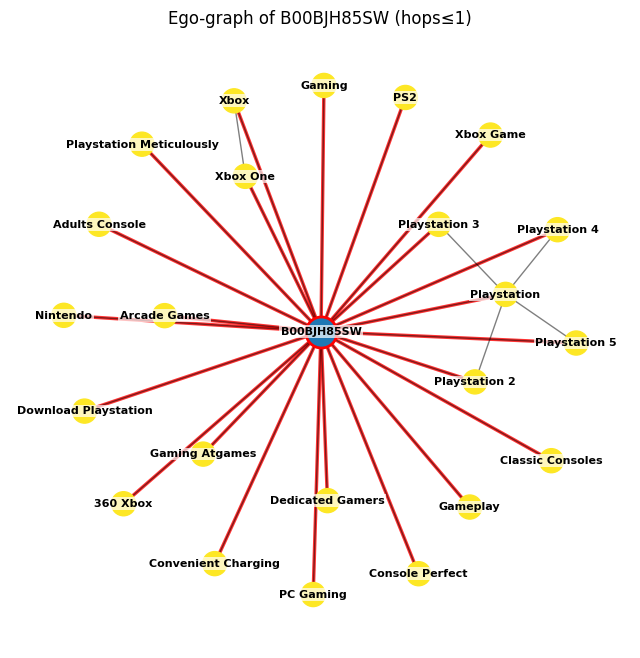

In [62]:
g_product = nx.from_pandas_edgelist(gemma_product, source='head', target='tail')
viz.draw_ego_hops(g_product, center_node="B00BJH85SW", hops=1)

Looking at the supgraph for the selected item with parent_asin "B00BJH85SW" we observe again structural and factual flaws. The item is connected to a lot of taxonomy entities with focus to consoles, which likely comes from the product _keyword: consoles players_. Looking at the product description can only explicitly detect a association to Nintendo, while all others are not mentioned. This is a flaw in the approach of  the taxonomy generation and bridging since it relies on the quality of keywords. The bigger issue strcuturally is that the item is connected to parents and grand parents like Playstation 5 and Playstytion, which impose high noise and redundancies. Therefore we will add to the current apporach a post processing step

For redundancy detection we now look how many items are connected to a specific parent and second level parent.

In [63]:
from collections import defaultdict
import pandas as pd
import networkx as nx

print("Building graph from relations DataFrame...")
G_relations = nx.DiGraph()
for _, row in gemma_relation.iterrows():
    h_str = str(row['head'])
    t_str = str(row['tail'])
    # Skip self-loops
    if h_str != t_str:
        G_relations.add_edge(h_str, t_str)
print(f"Graph built with {G_relations.number_of_nodes()} nodes and {G_relations.number_of_edges()} edges.")

import pandas as pd
import networkx as nx
TAXONOMY_PATH = "/Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/taxonomy/amazon-Video_Games"
MODEL_TECHNIQUE_NAME = "gemma3"

kg_filter = KG_Filter()

filtered_item_to_grandchild_relation = kg_filter.filter_item_to_grandchild_redundancy(gemma_relation)
filtered_item_to_grandchild_relation.to_csv(f"{TAXONOMY_PATH}/{MODEL_TECHNIQUE_NAME}_taxonomy-full-wo-grand-parents.csv", index=False)
gemma_wo_direct_parents = kg_filter.filter_redundant_direct_relations(gemma_relation)
gemma_wo_direct_parents.to_csv(f"{TAXONOMY_PATH}/{MODEL_TECHNIQUE_NAME}_taxonomy-full-wo-direct-parents.csv")

Building graph from relations DataFrame...
Graph built with 19399 nodes and 332153 edges.
No self-loops found in the taxonomy.


KeyboardInterrupt: 

Observable that wo-grand-parents redundancy taxonomy, where only direct parents are kept has 86.3 less links. Meanwhile if we only keep the highest level parent ("grand-parent")

Observable that 53% of relations are redundant. To be more precised items thatt are multiple connected have 88% redundant relationsships to parents. Therefore we remove redundancies. We use two approaches. First bottom up approach. This removes all relations from items to grand parents or further up. This method forces GNN KG to obtain more fine-grained information. Second top down approach. This removes all relations from items to parents. This method forces GNN KG to obtain more coarse-grained information.
